In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Load the data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

#Normalize pixel values to range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Class names for CIFAR-10 (in order of label index 0-9)
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer','Dog', 'Frog', 'Horse', 'Ship', 'Truck']

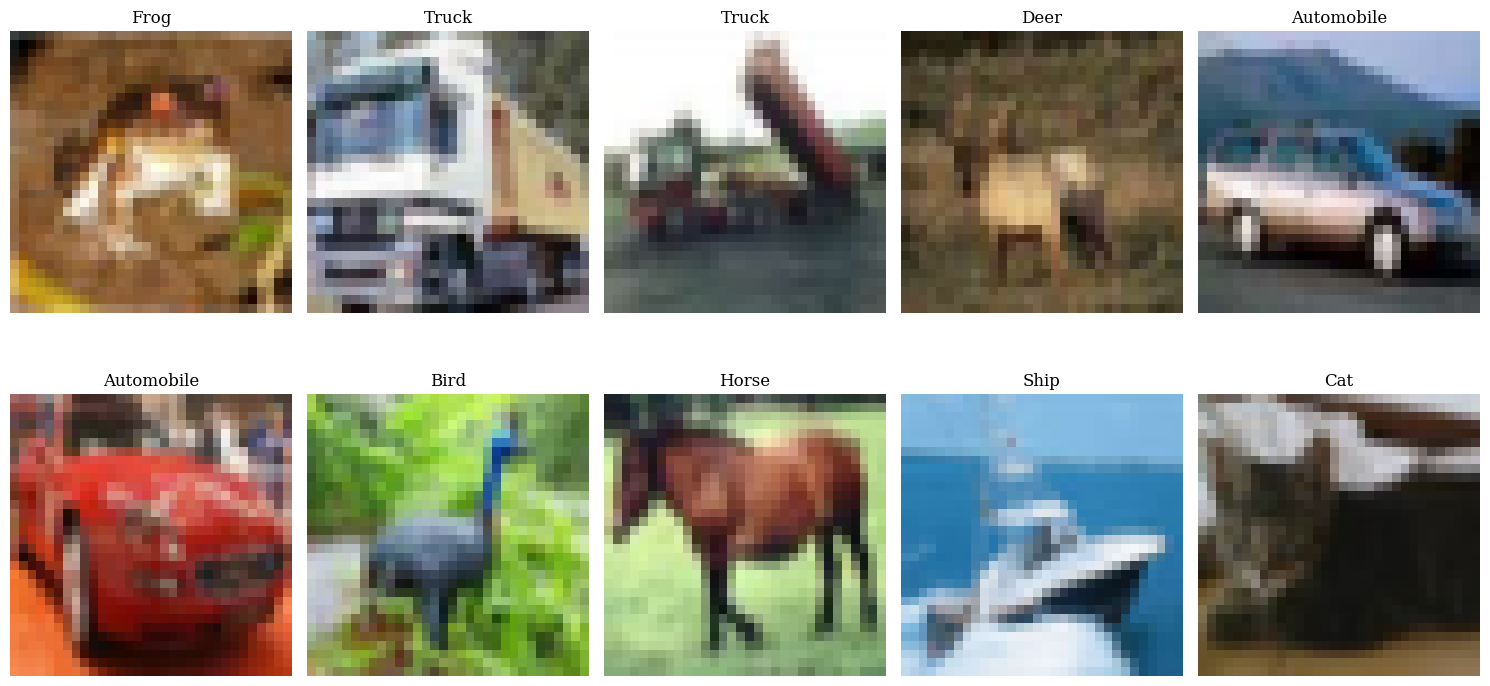

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


In [6]:
plt.figure(figsize=(15,8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontname='Serif')
    plt.axis('off')
plt.savefig("training_samples.png", format="png", dpi=600, bbox_inches="tight")
plt.tight_layout()
plt.show()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

In [9]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [8]:
input_shape = (32, 32, 3)

base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
output = Dense(10, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit(x_train, y_train_cat,validation_data=(x_test, y_test_cat),batch_size=32,epochs=15,verbose=1)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.5287 - loss: 1.3466 - val_accuracy: 0.5651 - val_loss: 1.2388
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5914 - loss: 1.1683 - val_accuracy: 0.5865 - val_loss: 1.1774
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6144 - loss: 1.1038 - val_accuracy: 0.5904 - val_loss: 1.1742
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6306 - loss: 1.0531 - val_accuracy: 0.6070 - val_loss: 1.1407
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6462 - loss: 1.0095 - val_accuracy: 0.6082 - val_loss: 1.1239
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6571 - loss: 0.9709 - val_accuracy: 0.6112 - val_loss: 1.1180
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6699 - loss: 0.9375 - val_accuracy: 0.6146 - val_loss: 1.1083
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6819 - 

In [12]:
# 1. Unfreeze the last convolutional block of VGG16
for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False


In [13]:
# Unfreeze only the last conv block (block5) — keep everything before it frozen
for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False
for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [15]:
# Re-compile with a LOWER learning rate — important for fine-tuning
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

# 2. Continue training (fine-tuning) for another 5-10 epochs
history_finetune = model.fit(x_train, y_train_cat,validation_data=(x_test, y_test_cat),batch_size=32,epochs=8,verbose=1)

Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.6429 - loss: 1.0325 - val_accuracy: 0.6906 - val_loss: 0.8870
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7273 - loss: 0.7764 - val_accuracy: 0.7101 - val_loss: 0.8398
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7703 - loss: 0.6486 - val_accuracy: 0.7291 - val_loss: 0.8194
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - accuracy: 0.8052 - loss: 0.5418 - val_accuracy: 0.7361 - val_loss: 0.7970
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.8407 - loss: 0.4405 - val_accuracy: 0.7377 - val_loss: 0.8810
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8751 - loss: 0.3448 - val_accuracy: 0.7353 - val_loss: 0.9076
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9024 - loss: 0.2690 - val_accuracy: 0.7405 - val_loss: 1.0134
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9250 - loss: 0

In [16]:
# 3. Compare accuracy before and after fine-tuning
initial_val_acc = max(history.history['val_accuracy'])
finetuned_val_acc = max(history_finetune.history['val_accuracy'])

print(f"Best Validation Accuracy BEFORE Fine-tuning: {initial_val_acc*100:.2f}%")
print(f"Best Validation Accuracy AFTER Fine-tuning:  {finetuned_val_acc*100:.2f}%")
print(f"Improvement: {(finetuned_val_acc - initial_val_acc)*100:.2f}%")

Best Validation Accuracy BEFORE Fine-tuning: 62.19%
Best Validation Accuracy AFTER Fine-tuning:  74.05%
Improvement: 11.86%


In [17]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, classification_report)
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
Test Accuracy : 74.05%
Precision     : 74.02%
Recall        : 74.05%
F1-score      : 73.91%


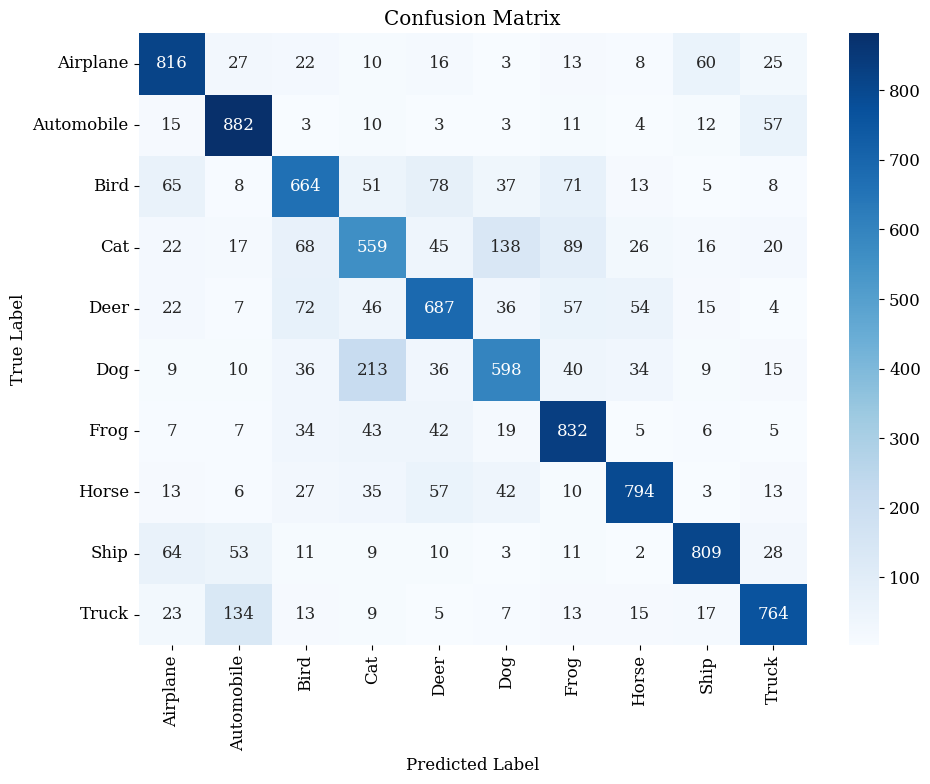

              precision    recall  f1-score   support

    Airplane       0.77      0.82      0.79      1000
  Automobile       0.77      0.88      0.82      1000
        Bird       0.70      0.66      0.68      1000
         Cat       0.57      0.56      0.56      1000
        Deer       0.70      0.69      0.69      1000
         Dog       0.67      0.60      0.63      1000
        Frog       0.73      0.83      0.78      1000
       Horse       0.83      0.79      0.81      1000
        Ship       0.85      0.81      0.83      1000
       Truck       0.81      0.76      0.79      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



In [19]:
# Set global plot styling (in case this is a fresh cell/session)
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['font.size'] = 12

# 1. Get predictions on the test set
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# 2. Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Precision     : {precision*100:.2f}%")
print(f"Recall        : {recall*100:.2f}%")
print(f"F1-score      : {f1*100:.2f}%")

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("confusion_matrix.eps", format="eps", bbox_inches="tight")
plt.show()

# 4. Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

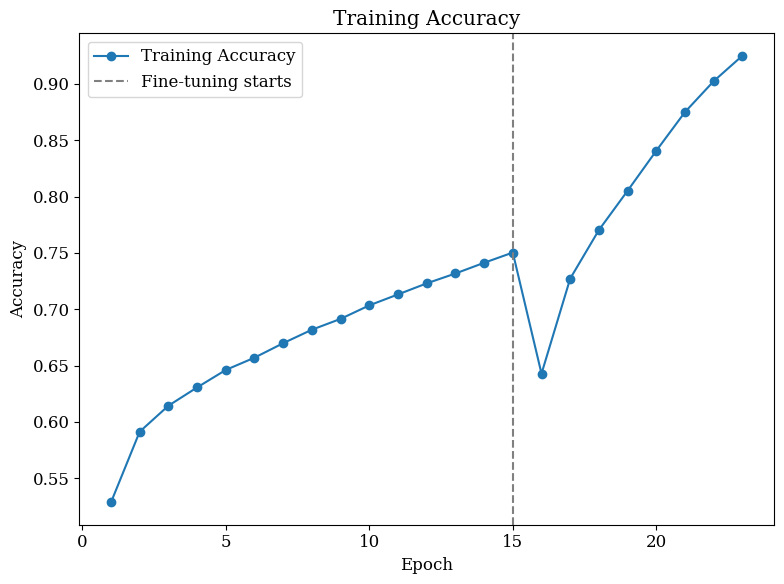

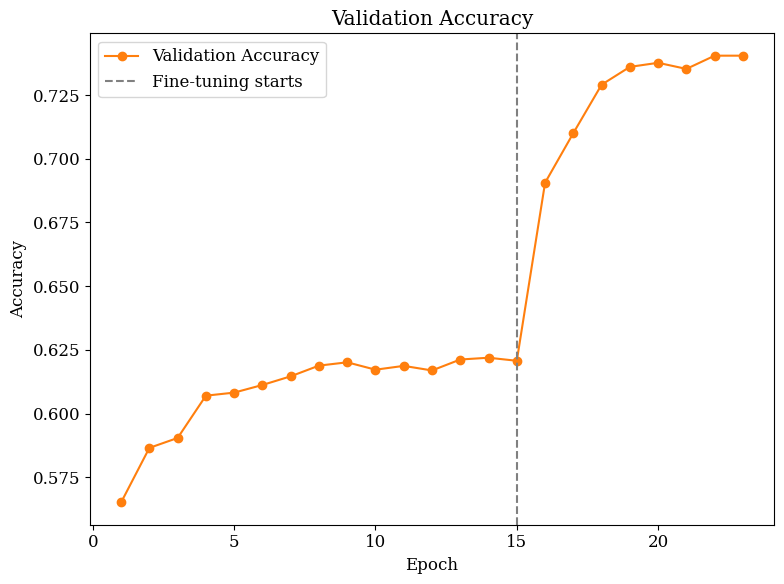

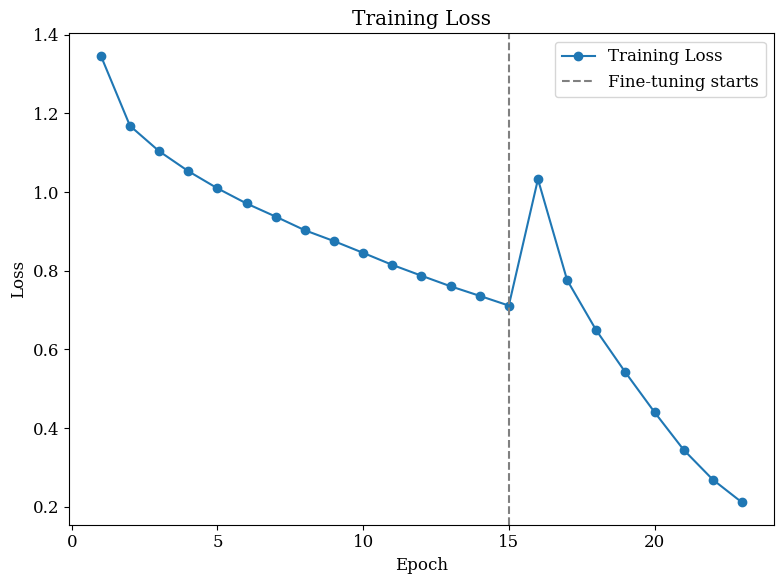

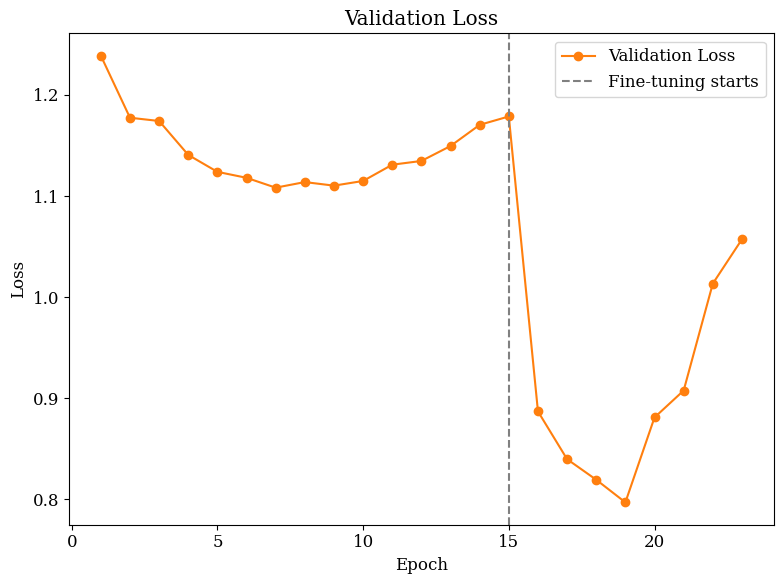

In [21]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Serif'
plt.rcParams['font.size'] = 12

# Combine initial training + fine-tuning histories
train_acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc   = history.history['val_accuracy'] + history_finetune.history['val_accuracy']
train_loss = history.history['loss'] + history_finetune.history['loss']
val_loss   = history.history['val_loss'] + history_finetune.history['val_loss']

epochs_range = range(1, len(train_acc) + 1)
finetune_start = len(history.history['accuracy'])  # epoch where fine-tuning began

# 2. Training Accuracy
plt.figure(figsize=(8,6))
plt.plot(epochs_range, train_acc, label='Training Accuracy', marker='o', color='tab:blue')
plt.axvline(x=finetune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig("training_accuracy.eps", format="eps", bbox_inches="tight")
plt.show()

# 3. Validation Accuracy
plt.figure(figsize=(8,6))
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='tab:orange')
plt.axvline(x=finetune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig("validation_accuracy.eps", format="eps", bbox_inches="tight")
plt.show()

# 4. Training Loss
plt.figure(figsize=(8,6))
plt.plot(epochs_range, train_loss, label='Training Loss', marker='o', color='tab:blue')
plt.axvline(x=finetune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.tight_layout()
plt.savefig("training_loss.eps", format="eps", bbox_inches="tight")
plt.show()

# 5. Validation Loss
plt.figure(figsize=(8,6))
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='tab:orange')
plt.axvline(x=finetune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig("validation_loss.eps", format="eps", bbox_inches="tight")
plt.show()